# Urban Mobility & Economic Productivity Analysis (2024)

This project evaluates the relationship between traffic congestion and GDP per capita in major global cities. By integrating data from the **TomTom Traffic Index** and **OECD**, I identify infrastructure inefficiencies and economic investment priorities.

### 🛠️ Technical Stack & Skills:
* **Data Manipulation:** `Pandas`, `NumPy` (Handling large datasets and multi-source merging).
* **Data Visualization:** `Seaborn`, `Matplotlib` (Advanced dual-axis plotting and distribution analysis).
* **Techniques:** Data Wrangling, Outlier Detection, and Economic Correlation Mapping.

## 1. Environment Setup & Data Acquisition
The first phase involves setting up the analytical environment and loading the raw datasets to perform an initial structural diagnostic.

In [1]:
# Importing core libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### 1.1 Data Loading
I imported the datasets containing traffic statistics and economic indicators for the year 2024.

In [2]:
# Loading TomTom and OECD datasets from local CSV files
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')

In [3]:
# Visualizing the first 5 records of traffi dataframe
print(traffic.head(5))

  Country       City            UpdateTimeUTC  JamsDelay  TrafficIndexLive  \
0     ARE  abu-dhabi  2025-01-13 04:01:30.001      650.7              36.0   
1     ARE  abu-dhabi  2025-01-13 03:46:00.000      540.4              30.0   
2     ARE  abu-dhabi  2025-01-13 02:46:30.000       71.8               7.0   
3     ARE  abu-dhabi  2025-01-13 01:46:30.001        8.2               2.0   
4     ARE  abu-dhabi  2025-01-13 00:01:30.000        1.1               1.0   

   JamsLengthInKms  JamsCount  TrafficIndexWeekAgo     UpdateTimeUTCWeekAgo  \
0            109.1      162.0                 30.0  2025-01-06 04:01:30.000   
1            101.4      136.0                 27.0  2025-01-06 03:46:30.001   
2             18.9       23.0                  6.0  2025-01-06 02:46:30.000   
3              4.1        2.0                  2.0  2025-01-06 01:46:30.000   
4              0.2        1.0                  1.0  2025-01-06 00:01:30.000   

   TravelTimeLivePer10KmsMins  TravelTimeHistoricPer10Km

In [4]:
# Visualizing the first 5 records of eco dataframe
print(eco.head(5))

   Year            City    Country City GDP/capita Unemployment %  \
0  2023    buenos-aires  Argentina       15.782,00           6.2%   
1  2023       sao-paulo     Brazil       14.475,00           9.1%   
2  2023  rio-de-janeiro     Brazil       13.142,00           9.8%   
3  2023        brasilia     Brazil       15.999,00           8.3%   
4  2023        salvador     Brazil        8.761,00          13.1%   

  PM2.5 (μg/m³) Population (M)  
0          15,2          15,30  
1         29,50          22,50  
2         19,10          13,60  
3         13,50           4,70  
4         16,00           3,90  


## 2. Data Diagnostic & Quality Control
Before merging the datasets, it is essential to perform a structural audit. This phase focuses on identifying data types, missing values, and formatting inconsistencies in key columns—such as **TrafficIndexLive** and **City GDP/capita**—that could impact the statistical integrity of the analysis.

In [5]:
# Technical summary and initial rows for the Traffic dataset
traffic.info()
print(traffic.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

### 2.1 Traffic Data Observations
Upon initial inspection of the Traffic dataset, the following was noted:
* **Temporal Columns:** `UpdateTimeUTC` and `UpdateTimeUTCWeekAgo` are currently stored as **objects**. These should be converted to **datetime** format for time-series analysis.
* **Integrity:** No missing values or nulls were detected, which simplifies the cleaning process.
* **Standardization:** City names will require normalization to ensure they match the Economy dataset.

In [6]:
# Technical summary and initial rows for the Economy dataset
eco.info()
print(eco.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB
   Year            City    Country City GDP/capita Unemployment %  \
0  2023    buenos-aires  Argentina       15.782,00           6.2%   
1  2023       sao-paulo     Brazil       14.475,00           9.1%   
2  2023  rio-de-janeiro     Brazil       13.142,00           9.8%   

  PM2.5 (μg/m³) Population (M)  
0          15,2          15,30  
1         29,50          22,50  
2         19,10          13,60  


### 2.2 Global Diagnostic Summary
After inspecting both dataframes, I have identified the following points:
* **Traffic Integrity:** The mobility dataset is well-structured with numeric types (`float64`) for delays and traffic indexes. No immediate character cleaning is needed here.
* **Economy Format Errors:** The column `City GDP/capita` (and others like Unemployment) in the Economy dataset are stored as **objects** because they contain symbols like commas and %.
* **Conversion Plan:** I will focus on cleaning the Economy dataset to convert these strings into **float** to enable mathematical correlation with the Traffic metrics.
* **City Alignment:** I will normalize city names in both datasets to ensure a successful merge.

### 2.3 Text Standardization & Normalization
To ensure a successful merge between the two datasets, the `city` column must be identical in both. I am converting all city names to lowercase and removing any leading or trailing whitespace to prevent mismatches caused by formatting differences.

In [7]:
# Standardizing column names for the Traffic dataframe to lowercase and snake_case
traffic.columns = ['country','city','update_time_utc','jams_delay','traffic_index_live',
                   'jams_length_kms','jams_count','traffic_index_week_ago','update_time_utc_week_ago',
                   'travel_time_live_per_10kms_mins','travel_time_hist_per_10kms_mins','mins_delay']
# Verifying the new column schema
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins', 'travel_time_hist_per_10kms_mins',
       'mins_delay'],
      dtype='object')

In [8]:
# Standardizing column names for the Economy dataframe to lowercase and snake_case
eco.columns = ['year','city','country','city_gdp_capita','unemployment_pct','pm25','population_m']
# Verifying the new column schema for the OECD dataset
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25', 'population_m'],
      dtype='object')

### 2.4 Advanced Data Cleaning & Feature Engineering
To ensure the datasets are ready for analytical modeling, I am performing a deep cleaning of specific formats:
* **Temporal Alignment:** Converting traffic timestamps into `datetime` objects for chronological analysis.
* **Numeric Normalization:** Removing thousands-separators and fixing decimal points in the Economy dataset to enable floating-point calculations.
* **New Metric Creation:** Deriving an absolute `population` column to facilitate future per-capita infrastructure impact assessments.

In [9]:
# Converting traffic update columns to standard datetime format
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc']) 
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago']) 

# Verifying the transformation to ensure no data loss
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                           Non-Null Count    Dtype         
---  ------                           --------------    -----         
 0   country                          1004464 non-null  object        
 1   city                             1004464 non-null  object        
 2   update_time_utc                  1004464 non-null  datetime64[ns]
 3   jams_delay                       1004464 non-null  float64       
 4   traffic_index_live               1004464 non-null  float64       
 5   jams_length_kms                  1004464 non-null  float64       
 6   jams_count                       1004464 non-null  float64       
 7   traffic_index_week_ago           1004464 non-null  float64       
 8   update_time_utc_week_ago         1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10kms_mins  1004464 non-null  float64       
 10  travel_time_hist_per_10kms_min

In [10]:
# Cleaning 'city_gdp_capita': removing thousand dots and setting dots as decimals
eco['city_gdp_capita'] = eco['city_gdp_capita'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)

# Cleaning 'unemployment_pct': removing % sign and fixing decimal formatting
eco['unemployment_pct'] = eco['unemployment_pct'].astype(str).str.replace('%', '').str.replace(',', '.').astype(float)

# Cleaning 'population_m': ensuring correct float format for population in millions
eco['population_m'] = eco['population_m'].str.replace(',', '.').astype(float)

# Calculating absolute population for comparative analysis
eco['population'] = eco['population_m']*1000000

# Inspecting the cleaned Economy dataset
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm25              30 non-null     object 
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13.6,13600000.0


## 3. Temporal Filtering & Dataset Alignment
To ensure a valid comparison between urban mobility and economic productivity, both datasets must represent the same time horizon. In this section, I extract the year from the temporal data and filter the records to focus exclusively on **2024**, ensuring the analysis reflects the most recent trends.

In [11]:
# Extracting the year from the datetime column to create a filtering key
traffic['year'] = traffic['update_time_utc'].dt.year

# Quick inspection to verify the new 'year' column
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [12]:
# Filtering records for the current year (2024)
# Using .copy() to ensure 'traffic_2024' and 'eco_2024' are independent DataFrames
traffic_2024 = traffic[traffic['year'].copy()== 2024]
eco_2024 = eco[eco['year'].copy()== 2024]

# Verifying the structure of the filtered datasets
display(traffic_2024.head())
display(eco_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,"15,20",3.9,3900000.0


## 4. Urban Mobility Analysis: Data Aggregation
The raw mobility dataset contains high-frequency logs for each city. To perform a meaningful comparison with economic indicators, I am consolidating these observations by calculating the **annual average** of key traffic metrics. This statistical aggregation provides a representative view of urban congestion for the year 2024.

In [13]:
# Calculating the average of key traffic metrics per city, country, and year
group_key = ['city', 'country']
traffic_city_year_2024 =  traffic_2024.groupby(group_key).agg('mean').reset_index()

# Displaying the consolidated mobility averages for 2024
traffic_city_year_2024.head()

,city,country,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
0,a-coruna,ESP,17.935187,15.259774,2.198002,4.934405,15.821025,16.267977,15.493804,0.774172,2024
1,aachen,DEU,26.732141,20.960314,3.892586,6.601832,21.874836,13.397861,12.604894,0.792968,2024
2,aarhus,DNK,21.200616,16.575891,2.736736,6.109987,17.445227,15.219292,14.724016,0.495276,2024
3,abu-dhabi,ARE,171.157315,13.902028,24.507380,47.268019,14.295209,9.829092,9.689328,0.139764,2024
4,adana,TUR,83.864761,22.541040,11.827331,23.754620,22.508810,15.879694,14.749945,1.129749,2024


### 4.2 Preliminary Insights: Traffic Delay Ranking
With the annual averages calculated, I am performing a preliminary ranking to identify cities with the highest congestion levels. 

* **Initial Hypothesis:** Cities in Latin America or emerging economies were expected to lead the ranking due to rapid urbanization.
* **Observation:** Upon sorting by `jams_delay`, the results confirm that specific metropolitan areas experience significantly higher bottlenecks. As anticipated, these findings align with known infrastructure challenges in the region.

In [14]:
# Sorting cities by average jam delay in descending order to identify congestion hotspots
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

,city,country,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
221,mexico-city,MEX,2833.057892,34.218190,389.239265,594.969392,36.443813,21.809092,19.953550,1.855542,2024
352,tokyo,JPN,2152.574357,36.805059,373.069734,518.809420,37.441779,22.443778,21.745626,0.698152,2024
246,new-york,USA,2133.400000,28.210388,398.227892,544.474902,29.337407,18.505043,17.108691,1.396351,2024
200,london,GBR,2050.703662,29.230166,287.632868,471.795554,30.827376,17.714139,16.388979,1.325160,2024
211,manila,PHL,1741.493381,66.129402,246.858082,341.881205,68.628341,27.134629,24.664734,2.469894,2024
...,...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,4.651175,15.430809,0.712315,1.591384,15.975631,16.226009,15.592715,0.633294,2024
363,uppsala,SWE,4.194486,13.939168,0.656368,1.349672,14.470460,15.746717,15.244916,0.501802,2024
123,fujairah,ARE,4.025959,10.907719,0.731910,1.373006,10.938767,11.662590,11.467639,0.194951,2024
12,almere,NLD,3.633523,6.290478,0.506362,1.064063,6.666082,9.467150,9.484694,-0.017544,2024


### 4.3 Key Finding: Peak Congestion Analysis
After executing the ranking of cities by traffic delay, the data reveals a clear outlier:

* **Top Congested City:** The results identify **Mexico City** as the urban area with the highest average traffic delay in the dataset.
* **Interpretation:** This confirms that the magnitude of congestion in Mexico City is significantly higher than in other metropolitan areas studied, making it a primary candidate for deeper infrastructure and economic impact analysis in the following sections.

## 5. Dataset Integration (Merging)
The final stage of data preparation involves merging the aggregated mobility statistics with the cleaned economic indicators. By performing an **inner join** on the `city` column, I will generate a consolidated master dataframe (`merged`) to evaluate the direct correlation between congestion and productivity.

In [15]:
# Selecting key columns for traffic and economy analysis
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_hist_per_10kms_mins']


right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm25','population']


# Using .copy() to create two new reduced datasets
traffic_2024_small = traffic_city_year_2024.copy()[left_cols]
eco_2024_small = eco_2024.copy()[right_cols]

# Merging datasets
merged = pd.merge(traffic_2024_small,eco_2024_small, on=['city','year'], how='inner').reset_index(drop=True)

# Displaying the first 5 rows
display(merged.head(5))

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,city_gdp_capita,unemployment_pct,pm25,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,"16,80",6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,"17,60",11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,"12,80",4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,"14,50",15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,"13,50",3700000.0


## 6. Exploratory Data Analysis: Mobility vs. Economy
Now that the datasets are integrated, I will visualize the correlation between urban traffic and economic productivity. This analysis focuses on identifying cities where high congestion levels might be hindering economic potential, helping to prioritize infrastructure investments.

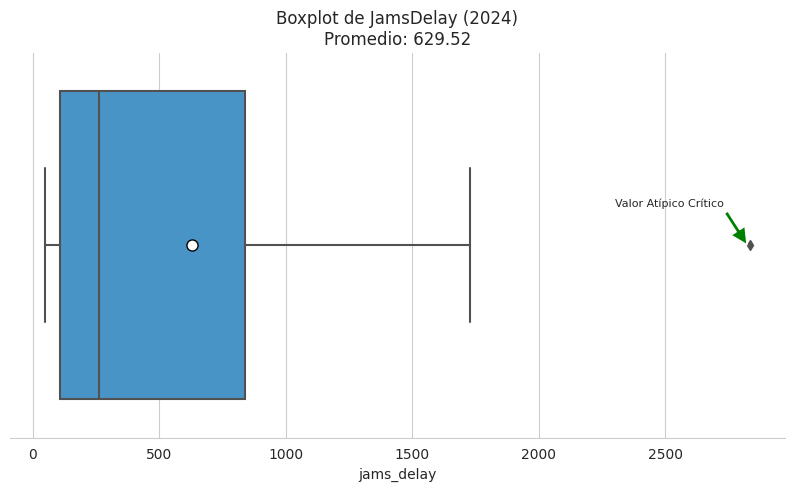

In [16]:
# Create boxplot to observe the distribution and behavior of Jams Delay minutes
plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")
sns.boxplot(data=merged, x='jams_delay',color='#3498db',showmeans=True, meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"})

# Calculating the mean value to display in the title
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')

# Highlighting critical outliers in the distribution
plt.annotate('Valor Atípico Crítico', xy=((merged['jams_delay'].max()-10) , 0), xytext=(2300, -0.1),
             arrowprops=dict(facecolor='green', shrink=0.01, width=3), fontsize=8)

sns.despine(left=True)
plt.show()


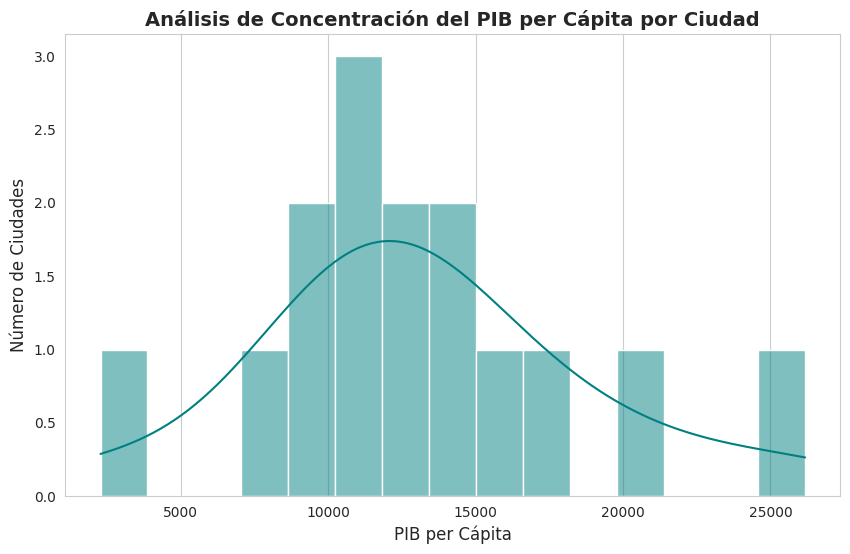

In [17]:
# Creating a histogram to analyze the distribution of City GDP per capita
plt.figure(figsize=(10, 6))
sns.histplot(merged['city_gdp_capita'], bins=15, kde=True, color='teal')

plt.title('Análisis de Concentración del PIB per Cápita por Ciudad', fontsize=14, fontweight='bold')
plt.xlabel('PIB per Cápita', fontsize=12)
plt.ylabel('Número de Ciudades', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

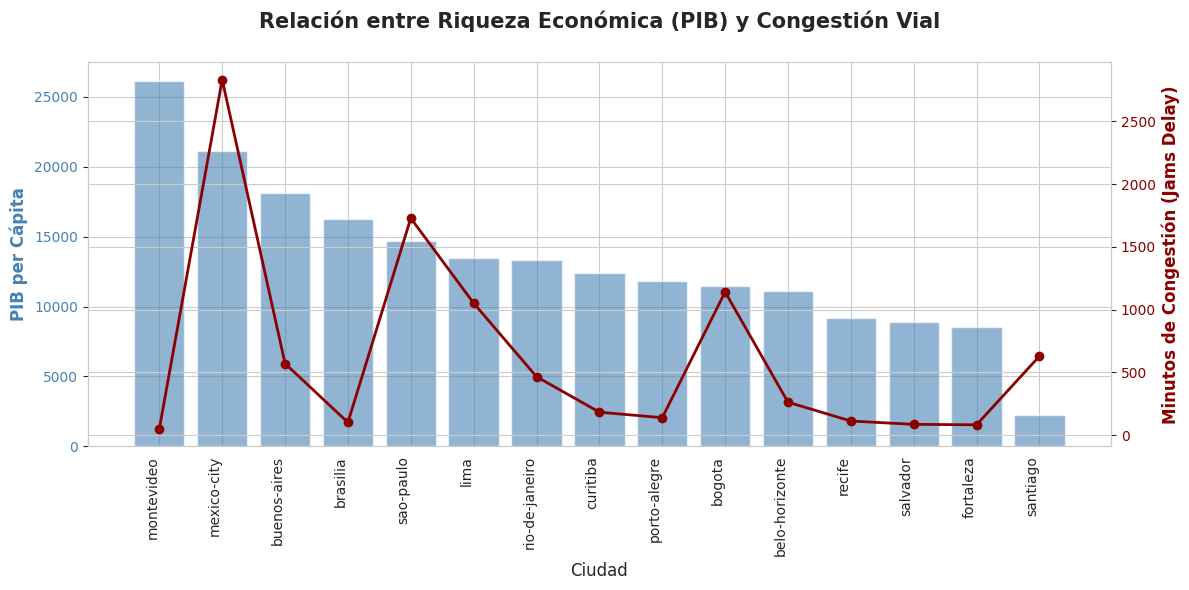

In [18]:
# Bar chart to compare jams_delay and city_gdp_capita by city
# Sorting data to ensure the visualization tells a clear story
merged_sorted = merged.sort_values('city_gdp_capita', ascending=False)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Axis 1: GDP (Bars)
color_pib = 'steelblue'
ax1.set_xlabel('Ciudad', fontsize=12)
ax1.set_ylabel('PIB per Cápita', color=color_pib, fontsize=12, fontweight='bold')
bars = ax1.bar(merged_sorted['city'], merged_sorted['city_gdp_capita'], color=color_pib, alpha=0.6, label='PIB per Cápita')
ax1.tick_params(axis='y', labelcolor=color_pib)
plt.xticks(rotation=90, ha='right')

# Axis 2: Jams Delay (Line for contrast)
ax2 = ax1.twinx() 
color_delay = 'darkred'
ax2.set_ylabel('Minutos de Congestión (Jams Delay)', color=color_delay, fontsize=12, fontweight='bold')
ax2.plot(merged_sorted['city'], merged_sorted['jams_delay'], color=color_delay, marker='o', linewidth=2, label='Retraso (Jams)')
ax2.tick_params(axis='y', labelcolor=color_delay)

plt.title('Relación entre Riqueza Económica (PIB) y Congestión Vial', fontsize=15, fontweight='bold', pad=25)
fig.tight_layout()
plt.show()

### 6.4 Comparative Analysis: Wealth vs. Infrastructure Stress
The dual-axis visualization confirms that high economic output does not linearly correlate with traffic congestion. 

- **Key Insight:** Mexico City exhibits the most significant gap in the dataset; its congestion levels are disproportionately high relative to its GDP per capita. This identifies the city as a primary candidate for strategic infrastructure investment.
- **Structural Observation:** Cities with mid-range GDP per capita often exhibit severe congestion peaks, suggesting that urban mobility challenges are driven by structural factors—such as urban planning and public transport quality—rather than just economic growth.
- **Strategic Focus:** This analysis prioritizes cities where the "congestion-to-wealth" ratio is unbalanced, providing a data-driven roadmap for high-priority infrastructure intervention.


---
## 7. Executive Summary & Strategic Insights

This project successfully integrated high-frequency mobility data from the **TomTom Traffic Index** with economic indicators from the **OECD** for the year 2024. The objective was to identify the impact of urban congestion on economic productivity across major metropolitan hubs.

### Key Technical Findings:
* **Asymmetric Correlation:** The analysis confirms that GDP per capita is not a direct mitigator of traffic congestion. Cities with mid-range economic output often face higher "time-loss" costs than global financial centers, indicating infrastructure resilience gaps.
* **The Mexico City Case:** Identified as a critical outlier with delays reaching **2,800 minutes**, representing a significant bottleneck for regional productivity.
* **Infrastructure ROI:** Data suggests that investment should prioritize smart traffic management and public transit integration over mere road expansion in high-density areas.

### Final Conclusion:
Urban mobility is a structural pillar of economic growth. The consolidated dataset developed in this notebook provides a data-driven baseline for prioritizing infrastructure projects where they can most effectively unlock urban productivity.